# MNIST Classification with blox

This tutorial demonstrates how to train a Convolutional Neural Network (CNN) on MNIST using **blox**.

We will strictly follow a probabilistic approach:
1.  **Model**: Defines a conditional distribution $P(Y | X)$.
2.  **Objective**: Maximize the likelihood of the data (minimize Negative Log Likelihood).

We use **Distrax** to handle the probability distributions.

In [1]:
# Setup: ensure blox is importable.
import sys

sys.path.insert(0, "../src")

# Install necessary packages.
!pip install -q optax tensorflow tensorflow-datasets matplotlib distrax

In [2]:
import blox as bx
import distrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import tensorflow as tf
import tensorflow_datasets as tfds

# Set random seed for reproducibility.
tf.random.set_seed(0)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
batch_size = 32
train_steps = 1200
eval_every = 200


def get_datasets(batch_size: int, train_steps: int):
  """Load MNIST datasets as tf.data Datasets."""

  def normalize(sample):
    image = tf.cast(sample['image'], tf.float32) / 255.0
    return {'image': image, 'label': sample['label']}

  train_ds = tfds.load('mnist', split='train')
  train_ds = train_ds.map(normalize)
  train_ds = train_ds.repeat().shuffle(1024)
  train_ds = train_ds.batch(batch_size, drop_remainder=True)
  train_ds = train_ds.take(train_steps).prefetch(-1)

  test_ds = tfds.load('mnist', split='test')
  test_ds = test_ds.map(normalize)
  test_ds = test_ds.batch(batch_size, drop_remainder=True).prefetch(-1)

  return train_ds, test_ds


train_ds, test_ds = get_datasets(batch_size, train_steps)
sample_batch = next(iter(train_ds.as_numpy_iterator()))
print(f'Batch shape: {sample_batch["image"].shape}')

2025-12-26 18:10:15.582305: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-12-26 18:10:18.369270: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Batch shape: (32, 28, 28, 1)


In [ ]:
class CNN(bx.Module):
  """A probabilistic CNN classifier."""

  def __init__(self, graph: bx.Graph, num_classes: int, rng: bx.Rng):
    super().__init__(graph)
    self.conv1 = bx.Conv(
        graph.child('conv1'), output_channels=32, kernel_size=(3, 3), rng=rng
    )
    self.conv2 = bx.Conv(
        graph.child('conv2'), output_channels=64, kernel_size=(3, 3), rng=rng
    )
    self.linear1 = bx.Linear(graph.child('linear1'), output_size=256, rng=rng)
    self.linear2 = bx.Linear(
        graph.child('linear2'), output_size=num_classes, rng=rng
    )
    self.dropout = bx.Dropout(graph.child('dropout'), rate=0.5, rng=rng)

  def __call__(self, params: bx.Params, x: jax.Array, is_training: bool = True):
    # Convolutional feature extraction.
    x, params = self.conv1(params, x)
    x = jax.nn.relu(x)
    x = bx.max_pool(x, window_shape=(2, 2), strides=(2, 2))

    x, params = self.conv2(params, x)
    x = jax.nn.relu(x)
    x = bx.max_pool(x, window_shape=(2, 2), strides=(2, 2))

    # Flatten and dense layers.
    x = x.reshape((x.shape[0], -1))
    x, params = self.linear1(params, x)
    x = jax.nn.relu(x)
    x, params = self.dropout(params, x, is_training=is_training)

    # Output logits for the Categorical distribution.
    logits, params = self.linear2(params, x)
    return logits, params

In [ ]:
# Create model components.
graph = bx.Graph('mnist')
rng = bx.Rng(graph.child('rng'))
model = CNN(graph.child('cnn'), num_classes=10, rng=rng)

# Initialize params with a sample batch item.
params = rng.seed(bx.Params(), seed=42)
_, params = model(params, sample_batch['image'][:1], is_training=False)
params = params.locked()

# Create a separate eval key for evaluation.
eval_key = jax.random.key(1)

bx.display(model.graph, params)

In [6]:
@jax.jit(static_argnames=['optimizer'], donate_argnames=['params', 'opt_state'])
def train_step(params, opt_state, batch_images, batch_labels, optimizer):
  trainable, non_trainable = params.split()

  def loss_fn(trainable):
    params = trainable.merge(non_trainable)
    logits, new_params = model(params, batch_images, is_training=True)

    # Probabilistic Loss: Negative Log Likelihood.
    dist = distrax.Categorical(logits=logits)
    loss = -dist.log_prob(batch_labels).mean()
    accuracy = jnp.mean(dist.mode() == batch_labels)

    _, new_non_trainable = new_params.split()
    return loss, ({'loss': loss, 'accuracy': accuracy}, new_non_trainable)

  grads, (metrics, new_non_trainable) = jax.grad(loss_fn, has_aux=True)(
      trainable
  )
  updates, new_opt_state = optimizer.update(grads, opt_state, trainable)
  new_trainable = optax.apply_updates(trainable, updates)

  return new_trainable.merge(new_non_trainable), new_opt_state, metrics

In [ ]:
@jax.jit
def eval_step(params, batch_images, batch_labels):
  """Evaluate a batch. Does not return params to avoid memory waste."""
  logits, _ = model(params, batch_images, is_training=False)
  dist = distrax.Categorical(logits=logits)
  loss = -dist.log_prob(batch_labels).mean()
  accuracy = jnp.mean(dist.mode() == batch_labels)
  return {'loss': loss, 'accuracy': accuracy}

In [ ]:
def train_model(params):
  optimizer = optax.adamw(1e-3)
  trainable_params, _ = params.split()
  opt_state = optimizer.init(trainable_params)

  # Track eval counter for unique RNG keys during evaluation.
  eval_counter = 0

  history = {
      'train_loss': [],
      'train_acc': [],
      'test_loss': [],
      'test_acc': [],
  }

  for step, batch in enumerate(train_ds.as_numpy_iterator()):
    params, opt_state, metrics = train_step(
        params, opt_state, batch['image'], batch['label'], optimizer
    )
    history['train_loss'].append(float(metrics['loss']))
    history['train_acc'].append(float(metrics['accuracy']))

    # Evaluate periodically.
    if (step + 1) % eval_every == 0:
      test_metrics = {'loss': [], 'accuracy': []}
      for test_batch in test_ds.as_numpy_iterator():
        # Fold in counter to eval_key for unique RNG each batch.
        eval_params = rng.seed(
            params, seed=jax.random.fold_in(eval_key, eval_counter)
        )
        eval_counter += 1

        metrics = eval_step(
            eval_params, test_batch['image'], test_batch['label']
        )
        test_metrics['loss'].append(metrics['loss'])
        test_metrics['accuracy'].append(metrics['accuracy'])

      test_loss = np.mean(test_metrics['loss'])
      test_acc = np.mean(test_metrics['accuracy'])
      history['test_loss'].append(test_loss)
      history['test_acc'].append(test_acc)

      train_loss = np.mean(history['train_loss'][-eval_every:])
      train_acc = np.mean(history['train_acc'][-eval_every:])
      print(
          f'Step {step + 1}: '
          f'train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, '
          f'test_loss={test_loss:.4f}, test_acc={test_acc:.4f}'
      )

  return params, history


trained_params, history = train_model(params)

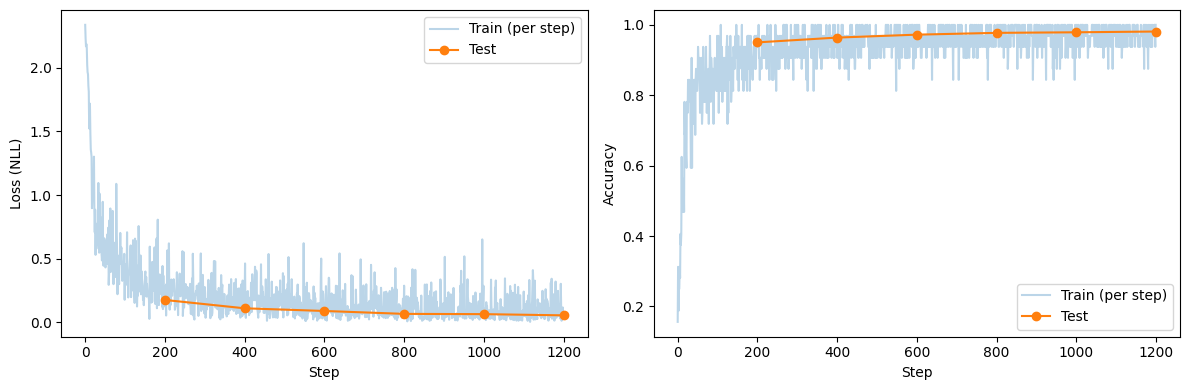

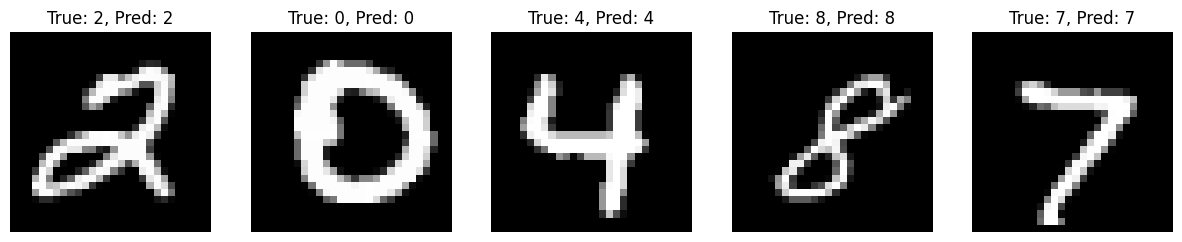

In [9]:
# Visualize Training Progress.
eval_steps = [eval_every * (i + 1) for i in range(len(history['test_acc']))]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], alpha=0.3, label='Train (per step)')
plt.plot(eval_steps, history['test_loss'], 'o-', label='Test')
plt.xlabel('Step')
plt.ylabel('Loss (NLL)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], alpha=0.3, label='Train (per step)')
plt.plot(eval_steps, history['test_acc'], 'o-', label='Test')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# Visualize Predictions.
def show_predictions(params, count=5):
  test_batch = next(iter(test_ds.as_numpy_iterator()))
  images = test_batch['image'][:count]
  labels = test_batch['label'][:count]
  logits, _ = model(params, images, is_training=False)

  dist = distrax.Categorical(logits=logits)
  preds = dist.mode()

  fig, axes = plt.subplots(1, count, figsize=(15, 3))
  for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'True: {labels[i]}, Pred: {preds[i]}')
    ax.axis('off')
  plt.show()


show_predictions(trained_params)